In [1]:
from pathlib import Path
from tempfile import TemporaryDirectory

import numpy as np
import scarf
import zarr

scarf.configure_output(level="ERROR", progress=False)
repository = scarf.cytebase.connect("scarf_docs")
mount_directory = TemporaryDirectory()
staged_dataset = repository.download_dataset(
    'tenx_5K_pbmc_rnaseq',
    destination=mount_directory.name,
    zarr=True,
)
source_path = staged_dataset / 'data.zarr'
target_path = Path(mount_directory.name) / 'analysis.zarr'

In [2]:
mounted = scarf.mount_datastore(
    str(source_path),
    at=str(target_path),
    default_assay='RNA',
    nthreads=4,
)

matrix_source = zarr.open_group(str(target_path), mode='r').attrs['matrixSource']
print('Target path:', target_path)
print('Target exists:', target_path.exists())
print('Downloaded dataset:', staged_dataset)
print('Mounted count source:', matrix_source['location'])
print('Mounted assays:', sorted(matrix_source['assays']))

Target path: /tmp/tmpnx0hpt2d/analysis.zarr
Target exists: True
Downloaded dataset: /tmp/tmpnx0hpt2d/tenx_5K_pbmc_rnaseq
Mounted count source: /tmp/tmpnx0hpt2d/tenx_5K_pbmc_rnaseq/data.zarr
Mounted assays: ['RNA']


In [3]:
target_root = zarr.open_group(str(target_path), mode='r')

print('Counts stored in target:', 'counts' in target_root['RNA'])
print('Mounted shape:', mounted.RNA.rawData.shape)

Counts stored in target: False
Mounted shape: (5025, 33538)


In [4]:
mounted_run = mounted.pipeline.run(
    filtering=False,
    hvg_count=500,
    pca_dims=15,
    leiden={"partitions": [0.5]},
    cell_cycle=False,
    paris=False,
    doublets=False,
    markers=False,
)
normalized = mounted_run["normalized"]
pca = mounted_run["pca"]

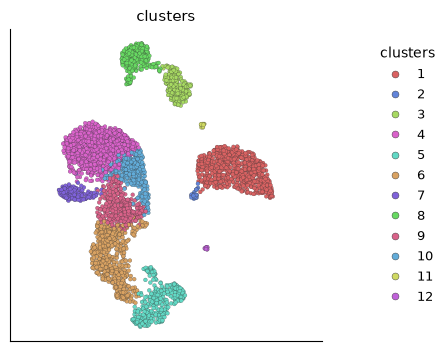

In [5]:
mounted.plots.embedding(run=mounted_run, color_by="clusters")

In [6]:
target_bytes = sum(
    path.stat().st_size
    for path in target_path.rglob("*")
    if path.is_file()
)
logical_count_bytes = int(
    np.prod(mounted.RNA.rawData.shape)
    * mounted.RNA.rawData.dtype.itemsize
)
print("Writable target bytes:", target_bytes)
print("Dense logical count bytes:", logical_count_bytes)

Writable target bytes: 9784146
Dense logical count bytes: 674113800


In [7]:
reopened = scarf.DataStore(
    str(target_path),
    nthreads=4,
)
reopened_run = reopened.pipeline.open(run_id=mounted_run.run_id)
same_counts = np.array_equal(
    reopened.RNA.rawData[:20, :20].compute(),
    mounted.RNA.rawData[:20, :20].compute(),
)
print('Counts still resolve:', same_counts)
print('Reopened pipeline status:', reopened_run.status)
print(
    'Normalization complete:',
    reopened.inspect_artifact(reopened_run['normalized']).complete,
)

Counts still resolve: True
Reopened pipeline status: completed
Normalization complete: True


In [8]:
scratch_directory = TemporaryDirectory()
scratch_dir = Path(scratch_directory.name) / 'pca_scratch'
pca_without_staging = mounted.run_pca(
    normalized,
    dims=15,
    local_cache=str(scratch_dir),
)
staged_bytes = sum(
    path.stat().st_size for path in scratch_dir.rglob('*') if path.is_file()
)
print('Local cache path:', scratch_dir)
print('Staged normalized bytes:', staged_bytes)
print('Local cache present after PCA:', scratch_dir.exists())
print('Reduction reused:', pca_without_staging == pca)

Local cache path: /tmp/tmps1a1ylgf/pca_scratch
Staged normalized bytes: 0
Local cache present after PCA: False
Reduction reused: True
